In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import WRFDomainLib
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pickle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
plt.rcParams["font.family"] = "Sans-Serif"

import xarray as xr

# Example usage
cmap = "BrBG"#inferno_white()


WPSFile = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/plotting_files/namelist.wps.txt'
wpsproj, latlonproj, corner_lat_full, corner_lon_full, length_x, length_y = WRFDomainLib.calc_wps_domain_info(WPSFile)
    

ERROR 1: PROJ: proj_create_from_database: Open of /home/amh001/space_fs7/software_2022/python/py_2024/share/proj failed


In [2]:
#load data
filepath='/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/seasonal_deltas_and_pvals_pr_rcp45_d03.npz'



data = np.load(filepath)
lat= data ['lat']
lon=data['lon']

In [3]:
season_data = {
    "DJF": (data["DJF_delta"], data["DJF_pval"]),
    "MAM": (data["MAM_delta"], data["MAM_pval"]),
    "JJA": (data["JJA_delta"], data["JJA_pval"]),
    "SON": (data["SON_delta"], data["SON_pval"])
}

In [4]:

filepath='/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/seasonal_deltas_and_pvals_pr_rcp45_CanRCM4.npz'
data = np.load(filepath)
latRCM4= data ['lat']
lonRCM4=data['lon']
season_data_RCM4 = {
    "DJF": (data["DJF_delta"], data["DJF_pval"]),
    "MAM": (data["MAM_delta"], data["MAM_pval"]),
    "JJA": (data["JJA_delta"], data["JJA_pval"]),
    "SON": (data["SON_delta"], data["SON_pval"])
}

In [5]:

filepath='/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/seasonal_deltas_and_pvals_pr_rcp45_CanESM2.npz'
data = np.load(filepath)
latESM2= data ['lat']
lonESM2=data['lon']
season_data_ESM2 = {
    "DJF": (data["DJF_delta"], data["DJF_pval"]),
    "MAM": (data["MAM_delta"], data["MAM_pval"]),
    "JJA": (data["JJA_delta"], data["JJA_pval"]),
    "SON": (data["SON_delta"], data["SON_pval"])
}

In [6]:
path0='/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/ensemble_means/NA-CORDEX_ensemble/'
def loadseason(season,path0):
    file0=path0+f'CORDEX_pr_change_rcp45_{season}.nc'
    ds = xr.open_dataset(file0)

    # Replace 'pr_delta' and 'pr_pval' with the actual variable names in the NetCDF
    delta = ds["pr_relanom"].values
    file0=path0+f'CORDEX_pr_change_rcp45_{season}_robustness.nc'
    ds = xr.open_dataset(file0)
    robust= ds["pr_anom_robustness"].values
    file0=path0+f'CORDEX_pr_change_rcp45_{season}_consensus.nc'
    ds = xr.open_dataset(file0)
    cons = ds["pr_anom_consensus"].values
    #masked_grid = robust 
    masked_grid=(cons < 0.8) & (robust < 0.66) #mask is true where not sig
    lat = ds["lat"].values
    lon=ds['lon'].values
    return delta, masked_grid, lat, lon
seasons= ["DJF", "MAM", "JJA", "SON"];
season_data_CORDEX = {}

for season in seasons:
    delta, mask,latCORD, lonCORD=loadseason(season,path0)
    season_data_CORDEX[season] = (delta, mask)

In [7]:
path0='/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/ensemble_means/CMIP5_ensemble/'
def loadseason(season,path0):
    file0=path0+f'CMIP5_pr_change_rcp45_{season}.nc'
    ds = xr.open_dataset(file0)

    # Replace 'pr_delta' and 'pr_pval' with the actual variable names in the NetCDF
    delta = ds["pr_relanom"].values
    file0=path0+f'CMIP5_pr_change_rcp45_{season}_robustness.nc'
    ds = xr.open_dataset(file0)
    robust= ds["pr_anom_robustness"].values
    file0=path0+f'CMIP5_pr_change_rcp45_{season}_consensus.nc'
    ds = xr.open_dataset(file0)
    cons = ds["pr_anom_consensus"].values
    #masked_grid = robust 
    masked_grid=(cons < 0.8) & (robust < 0.66) #mask is true where not sig
    lat = ds["lat"].values
    lon=ds['lon'].values
    return delta, masked_grid, lat, lon
seasons= ["DJF", "MAM", "JJA", "SON"];
season_data_CMIP5= {}

for season in seasons:
    delta, mask,latCMIP5, lonCMIP5=loadseason(season,path0)
    season_data_CMIP5[season] = (delta, mask)

In [8]:



#mpl.rcParams['hatch.color'] = 'gray'
def plotseasons(j, count, season_data, axes, seasons, nmodels, var, lon, lat, label0):
#j=0
#count=0

    #print(vmin, vmax)
    for i, season in enumerate(seasons):
        ax = axes[i, j] if nmodels > 1 else axes[i]
        field = season_data[season][0]
        pval  = season_data[season][1]
        #print('D3 pvals', np.amax(pval), np.amin(pval))
        # Main colormap
        #print(vmin, vmax)
        mesh = ax.pcolormesh(
            lon, lat, field,
            cmap=cmap, vmin=vmin,vmax=vmax,
            transform=ccrs.PlateCarree()    )
        #meshes.append(mesh)
    
        
        cs = ax.contourf(
            lon, lat, pval,
            levels=[0.1, 1],
            colors="none", 
            hatches=hatches,  # pass as a list
            transform=ccrs.PlateCarree()
        )
        coastline = cf.COASTLINE.with_scale('10m')
        ax.add_feature(coastline, linewidth=0.1, edgecolor='black')

    
        ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
        if j==0:
            ax.text(-0.18, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())
        if season=='DJF':
            ax.set_title(label0)
        count+=1


    return count, mesh

In [9]:



#mpl.rcParams['hatch.color'] = 'gray'
def plotseasons_ens(j, count, season_data, axes, seasons, nmodels, var, lon, lat,label0):
#j=0
#count=0

    #print(vmin, vmax)
    for i, season in enumerate(seasons):
        ax = axes[i, j] if nmodels > 1 else axes[i]
        field = season_data[season][0]
        mask  = season_data[season][1]
        #print('D3 pvals', np.amax(pval), np.amin(pval))
        # Main colormap
        #print(vmin, vmax)
        mesh = ax.pcolormesh(
            lon, lat, field,
            cmap=cmap, vmin=vmin,vmax=vmax,
            transform=ccrs.PlateCarree()    )
        #meshes.append(mesh)
    
        #~msk is true where sig
        cs = ax.contourf(
            lon, lat, ~mask,
            levels=[0, 0.9],
            colors="none", 
            hatches=hatches,  # pass as a list
            transform=ccrs.PlateCarree()
        )
        coastline = cf.COASTLINE.with_scale('10m')
        ax.add_feature(coastline, linewidth=0.1, edgecolor='black')

    
        ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
        if j==0:
            ax.text(-0.18, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())
        if season=='DJF':
            ax.set_title(label0)
        count+=1


    return count, mesh

4


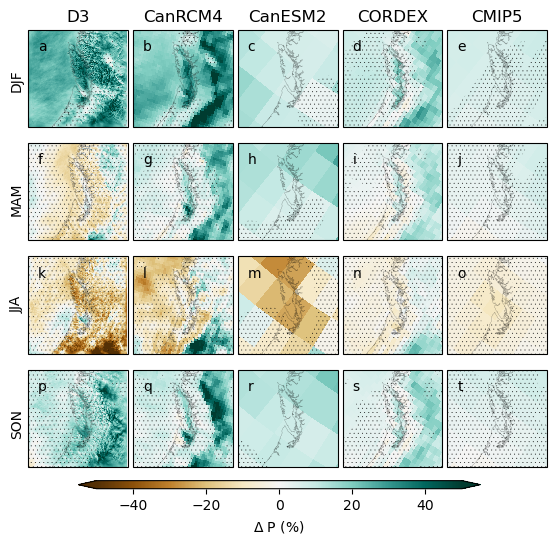

In [10]:

mpl.rcParams['hatch.linewidth'] = 0.1
mpl.rcParams['patch.edgecolor']='none'
nrows = len(seasons)
ncols = 5
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

at=0.1;bt=0.9

nmodels=5;vmin=-50;vmax=50
hatches = ["..."]
# Hatching where pval < 0.1
dense_dots = "." * 2  # repeat the dot
hatches = [dense_dots + " " + dense_dots]  # optional spacing
#seasons = [ 'SON', 'JJA', 'MAM','DJF']
seasons = ["DJF", "MAM", "JJA", "SON"]
fig, axes = plt.subplots(
        nrows=len(seasons), ncols=nmodels,
        figsize=(6.7,5.4),
        subplot_kw={"projection": wpsproj}
    )
j=0
count=0




count,mesh=plotseasons(j, count, season_data, axes, seasons, nmodels, 't2', lon, lat, 'D3')
print(count)
j=1
count,mesh= plotseasons(j, count, season_data_RCM4, axes, seasons, nmodels, 't2', lonRCM4, latRCM4, 'CanRCM4')
j=2
count,mesh = plotseasons(j, count, season_data_ESM2, axes, seasons, nmodels, 't2', lonESM2, latESM2, 'CanESM2')
j=3
#The CORDEX and CMIP5 use a mak instead of P-values. it's true where not significant, so we can mask out those areas[0,0.9]
count,mesh = plotseasons_ens(j, count, season_data_CORDEX, axes, seasons, nmodels, 't2', lonCORD, latCORD, 'CORDEX')
j=4
count,mesh = plotseasons_ens(j, count, season_data_CMIP5, axes, seasons, nmodels, 't2', lonCMIP5, latCMIP5, 'CMIP5')

fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05)

# One shared colorbar
cbar_ax = fig.add_axes([0.2, 0.02, 0.6, 0.015])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both', orientation="horizontal")
cbar.set_label(r"$\Delta$ P (%)")


plt.savefig('Figures/pr_RCP45_means.png', format='png', bbox_inches='tight',transparent=False,dpi=500)

DJF
D3 pvals nan nan
D3 pvals nan nan
D3 pvals nan nan
D3 pvals nan nan
DJF
DJF RCM4 pvals 0.9998782993285487 1.49566662796825e-11
RCM4 field 134.07797 -64.606224
MAM RCM4 pvals 0.9999721676879869 1.8107364315967906e-06
RCM4 field 247.49765 -81.41752
JJA RCM4 pvals 0.9999754449565401 3.021015630612064e-08
RCM4 field 222.3747 -84.54873
SON RCM4 pvals 0.9999971742327548 4.907035713377352e-08
RCM4 field 125.55461 -71.09916
DJF
ESM2 pvals 0.9986676185803955 8.464902262166506e-35
ESM2 pvals 0.9995353678994718 1.8682878141978842e-33
ESM2 pvals 0.9999083029155478 8.67788079887482e-48
ESM2 pvals 0.9999278030447318 7.500609644993365e-37
DJF
DJF


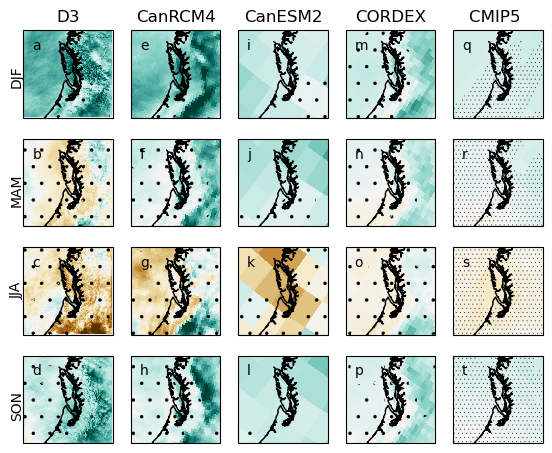

In [11]:
subpanel=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
at=0.1;bt=0.9
import matplotlib.colors as colors
import numpy as np
nmodels=5;vmin=-50;vmax=50
hatches = ["..."]
# Hatching where pval < 0.1
dense_dots = "." * 3  # repeat the dot
hatches = dense_dots + " " + dense_dots  # optional spacing

seasons = ["DJF", "MAM", "JJA", "SON"]
fig, axes = plt.subplots(
        nrows=len(seasons), ncols=nmodels,
        figsize=(6.7,5.4),
        subplot_kw={"projection": wpsproj}
    )
j=0
count=0
for i, season in enumerate(seasons):

    ax = axes[i, j] if nmodels > 1 else axes[i]
    if count==0:
        ax.set_title('D3')
        print(season)
    field = season_data[season][0]
    pval  = season_data[season][1]
    print('D3 pvals', np.amax(pval), np.amin(pval))
    # Main colormap
    mesh = ax.pcolormesh(
        lon, lat, field,
        cmap=cmap, vmin=vmin,vmax=vmax,
        transform=ccrs.PlateCarree()    )
    #meshes.append(mesh)

    # Hatching where pval < 0.1
    #masked_grid = np.ma.masked_where(pval >= 0.1, pval)
    ax.contourf(
        lon, lat,pval,
        levels=[0.1, 1], colors="none", hatches=hatches,
        transform=ccrs.PlateCarree()
    )
  #  ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

#    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    # Coastlines
    ax.coastlines()
    ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
    
    ax.text(-0.15, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())
    
    count+=1
##################CanRCM4  ##########3


j=1

for i, season in enumerate(seasons):

    ax = axes[i, j] if nmodels > 1 else axes[i]
    if season=='DJF':
        ax.set_title('CanRCM4')
        print(season)
    field = season_data_RCM4[season][0]
    pval  = season_data_RCM4[season][1]
    print(season, 'RCM4 pvals', np.amax(pval), np.amin(pval))
    print('RCM4 field', np.amax(field), np.amin(field))

    # Main colormap
    mesh = ax.pcolormesh(
        lonRCM4, latRCM4, field,
        cmap=cmap, vmin=vmin,vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    #meshes.append(mesh)

    # Hatching where pval < 0.1
    #masked_grid = np.ma.masked_where(pval >= 0.1, pval)
    ax.contourf(
        lonRCM4, latRCM4, pval,
        levels=[0.1,1], colors="none", hatches=hatches,
        transform=ccrs.PlateCarree()
    )
  #  ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

#    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    # Coastlines
    ax.coastlines()
    ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
    
   # ax.text(-0.15, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

    count+=1
######CANESM2



j=2

for i, season in enumerate(seasons):

    ax = axes[i, j] if nmodels > 1 else axes[i]
    if season=='DJF':
        ax.set_title('CanESM2')
        print(season)
    field = season_data_ESM2[season][0]
    pval  = season_data_ESM2[season][1]
    print('ESM2 pvals', np.amax(pval), np.amin(pval))

    # Main colormap
    mesh = ax.pcolormesh(
        lonESM2, latESM2, field,
        cmap=cmap, vmin=vmin,vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    #meshes.append(mesh)

    # Hatching where pval < 0.1
    #masked_grid = np.ma.masked_where(pval >= 0.1, pval)
    ax.contourf(
        lonESM2, latESM2, pval,
        levels=[0.1, 1], colors="none", hatches=hatches,
        transform=ccrs.PlateCarree()
    )
  #  ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

#    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    # Coastlines
    ax.coastlines()
    ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
    
   # ax.text(-0.15, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

    count+=1



j=3

for i, season in enumerate(seasons):

    ax = axes[i, j] if nmodels > 1 else axes[i]
    if season=='DJF':
        ax.set_title('CORDEX')
        print(season)
    field = season_data_CORDEX[season][0]
    mask  = season_data_CORDEX[season][1]

    # Main colormap
    mesh = ax.pcolormesh(
        lonCORD, latCORD, field,
        cmap=cmap, vmin=vmin,vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    #meshes.append(mesh)

    # Hatching where pval < 0.1
    ax.contourf(
        lonCORD, latCORD, ~mask,
        levels=[0, 0.9], colors="none", hatches=hatches,
        transform=ccrs.PlateCarree()
    )
  #  ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

#    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    # Coastlines
    ax.coastlines()
    ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
    
   # ax.text(-0.15, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

    count+=1
j=4

for i, season in enumerate(seasons):

    ax = axes[i, j] if nmodels > 1 else axes[i]
    if season=='DJF':
        ax.set_title('CMIP5 ')
        print(season)
    field = season_data_CMIP5[season][0]
    mask  = season_data_CMIP5[season][1]

    # Main colormap
    mesh = ax.pcolormesh(
        lonCMIP5, latCMIP5, field,
        cmap=cmap, vmin=vmin,vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    #meshes.append(mesh)

    # Hatching where pval < 0.1
    ax.contourf(
        lonCMIP5, latCMIP5, ~mask,
        levels=[0, 0.9], colors="none", hatches=["...."],
        transform=ccrs.PlateCarree()
    )
  #  ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

#    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    # Coastlines
    ax.coastlines()
    ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
    
   # ax.text(-0.15, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

    count+=1


#plt.savefig('pr_RCP45_means.png', format='png', bbox_inches='tight',transparent=False,dpi=500)

In [12]:
import seaborn as sns
